# Gemma 4 Speed Benchmark Notebook
Baseline vs MTP speculative decoding benchmark for Google Colab.


In [ ]:
!pip install -q torch transformers>=4.53.0 accelerate bitsandbytes sentencepiece huggingface_hub pandas numpy matplotlib seaborn psutil tqdm


In [ ]:
pip install --upgrade transformers

In [ ]:
import os, time, subprocess, shutil, threading, platform, json
from pathlib import Path
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TextIteratorStreamer

if not torch.cuda.is_available():
    raise RuntimeError('GPU runtime required')

GPU_NAME = torch.cuda.get_device_name(0)
GPU_CC = torch.cuda.get_device_capability(0)
TOTAL_VRAM_GB = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2)
BF16_SUPPORTED = GPU_CC[0] >= 8
print(GPU_NAME, GPU_CC, TOTAL_VRAM_GB)


Tesla T4 (7, 5) 14.56


In [ ]:
# Optional: os.environ['HF_TOKEN']='hf_xxx'
HF_TOKEN = os.environ.get('HF_TOKEN', None)
##ASSISTANT_MODEL_ID='google/gemma-4-26B-A4B-it-assistant'
TARGET_MODEL_ID = "google/gemma-4-E4B-it"
ASSISTANT_MODEL_ID = "google/gemma-4-E4B-it-assistant"

In [ ]:
max_memory = {
    0: "14GiB",   # For T4
    "cpu": "64GiB"
}

In [ ]:
def build_quant_config():
    return BitsAndBytesConfig(load_in_4bit=True,bnb_4bit_quant_type='nf4',bnb_4bit_use_double_quant=True,bnb_4bit_compute_dtype=torch.bfloat16 if BF16_SUPPORTED else torch.float16)

def cleanup_cuda():
    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()

def gpu_snapshot():
    if shutil.which('nvidia-smi') is None: return {}
    out = subprocess.check_output(['nvidia-smi','--query-gpu=memory.used,memory.total,utilization.gpu','--format=csv,noheader,nounits'], text=True).strip().splitlines()[0]
    used,total,util = [x.strip() for x in out.split(',')]
    return {'memory_used_mb': float(used), 'memory_total_mb': float(total), 'utilization_gpu_pct': float(util)}


In [ ]:
def build_quant_config():
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16 if BF16_SUPPORTED else torch.float16,
        llm_int8_enable_fp32_cpu_offload=True
    )

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(TARGET_MODEL_ID, token=HF_TOKEN if HF_TOKEN else None)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

#target_model = AutoModelForCausalLM.from_pretrained(TARGET_MODEL_ID, device_map='auto', quantization_config=build_quant_config(), torch_dtype=torch.bfloat16 if BF16_SUPPORTED else torch.float16, token=HF_TOKEN if HF_TOKEN else None)
max_memory = {
    0: "14GiB",   # For T4
    "cpu": "64GiB"
}
target_model = AutoModelForCausalLM.from_pretrained(
    TARGET_MODEL_ID,
    quantization_config=build_quant_config(),
    device_map="auto",
    max_memory=max_memory,
    offload_folder="./offload_target",
    offload_state_dict=True,
    low_cpu_mem_usage=True,
    torch_dtype=torch.bfloat16 if BF16_SUPPORTED else torch.float16,
    token=HF_TOKEN if HF_TOKEN else None
)
#assistant_model = AutoModelForCausalLM.from_pretrained(ASSISTANT_MODEL_ID, device_map='auto', quantization_config=build_quant_config(), torch_dtype=torch.bfloat16 if BF16_SUPPORTED else torch.float16, token=HF_TOKEN if HF_TOKEN else None)
assistant_model = AutoModelForCausalLM.from_pretrained(
    ASSISTANT_MODEL_ID,
    quantization_config=build_quant_config(),
    device_map="auto",
    max_memory=max_memory,
    offload_folder="./offload_assistant",
    offload_state_dict=True,
    low_cpu_mem_usage=True,
    torch_dtype=torch.bfloat16 if BF16_SUPPORTED else torch.float16,
    token=HF_TOKEN if HF_TOKEN else None
)
DEVICE = next(target_model.parameters()).device
print('Loaded on', DEVICE)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/159M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/50 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/307 [00:00<?, ?B/s]

Loaded on cuda:0


In [ ]:
PROMPTS=[('short','Explain speculative decoding.'),('math','100 tok/s to 250 tok/s speedup?'),('code','Python tokens/sec benchmark function')]
MAX_NEW_TOKENS=64
REPEATS=3


In [ ]:
def measure_ttft(prompt, use_assistant=False):
    inputs = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    streamer = TextIteratorStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)
    kwargs=dict(**inputs,max_new_tokens=MAX_NEW_TOKENS,do_sample=False,streamer=streamer,pad_token_id=tokenizer.eos_token_id)
    if use_assistant: kwargs['assistant_model']=assistant_model
    def run():
        with torch.inference_mode(): target_model.generate(**kwargs)
    start=time.perf_counter(); t=threading.Thread(target=run); t.start(); first=None
    for chunk in streamer:
        if chunk:
            first=time.perf_counter()-start; break
    t.join(); return first


In [ ]:
results=[]
for pname, prompt in PROMPTS:
    for mode in ['baseline','mtp']:
        for run in range(REPEATS):
            cleanup_cuda()
            inputs=tokenizer(prompt, return_tensors='pt').to(DEVICE)
            prompt_len=inputs['input_ids'].shape[-1]
            kwargs=dict(**inputs,max_new_tokens=MAX_NEW_TOKENS,do_sample=False,pad_token_id=tokenizer.eos_token_id,return_dict_in_generate=True)
            if mode=='mtp': kwargs['assistant_model']=assistant_model
            ttft=measure_ttft(prompt, use_assistant=(mode=='mtp'))
            torch.cuda.synchronize(); start=time.perf_counter()
            with torch.inference_mode(): out=target_model.generate(**kwargs)
            torch.cuda.synchronize(); end=time.perf_counter()
            seq=out.sequences[0]; out_tokens=int(seq.shape[-1]-prompt_len)
            latency=end-start
            results.append({'prompt':pname,'mode':mode,'run':run+1,'output_tokens':out_tokens,'latency_s':latency,'ttft_s':ttft,'tokens_per_sec':out_tokens/latency,'peak_mem_mb':torch.cuda.max_memory_allocated()/1024**2, **gpu_snapshot()})
results_df=pd.DataFrame(results)
results_df


,prompt,mode,run,output_tokens,latency_s,ttft_s,tokens_per_sec,peak_mem_mb,memory_used_mb,memory_total_mb,utilization_gpu_pct
0,short,baseline,1,64,22.036941,2.628530,2.904214,9072.887207,9273.0,15360.0,19.0
1,short,baseline,2,64,10.003901,0.215607,6.397504,9084.687012,9285.0,15360.0,30.0
2,short,baseline,3,64,10.780514,0.258951,5.936637,9084.687988,9285.0,15360.0,40.0
3,short,mtp,1,64,4.176557,0.202686,15.323627,9109.819336,9287.0,15360.0,53.0
4,short,mtp,2,64,3.904603,0.196693,16.390911,9109.809570,9287.0,15360.0,39.0
5,short,mtp,3,64,3.641916,0.235351,17.573165,9109.809570,9287.0,15360.0,48.0
6,math,baseline,1,64,10.595678,0.525564,6.040199,9085.071777,9287.0,15360.0,40.0
7,math,baseline,2,64,10.517322,0.188694,6.085199,9085.792480,9287.0,15360.0,37.0
8,math,baseline,3,64,10.546048,0.190954,6.068624,9085.792480,9289.0,15360.0,43.0
9,math,mtp,1,64,9.629203,0.199355,6.646448,9112.073730,9291.0,15360.0,56.0


In [ ]:
summary=results_df.groupby(['prompt','mode'])[['latency_s','ttft_s','tokens_per_sec','peak_mem_mb']].mean().reset_index()
comparison=results_df.pivot_table(index='prompt', columns='mode', values='tokens_per_sec', aggfunc='mean')
comparison['speedup_x']=comparison['mtp']/comparison['baseline']
print(summary)
print(comparison)


  prompt      mode  latency_s    ttft_s  tokens_per_sec  peak_mem_mb
0   code  baseline  10.770268  0.226956        5.947150  9085.055176
1   code       mtp   4.983892  0.322687       13.933658  9110.094076
2   math  baseline  10.553016  0.301737        6.064674  9085.552246
3   math       mtp   9.579428  0.196863        6.681081  9112.067220
4  short  baseline  14.273785  1.034363        5.079452  9080.754069
5  short       mtp   3.907692  0.211577       16.429235  9109.812826
mode    baseline        mtp  speedup_x
prompt                                
code    5.947150  13.933658   2.342913
math    6.064674   6.681081   1.101639
short   5.079452  16.429235   3.234450


In [ ]:
outdir=Path('./gemma4_outputs'); outdir.mkdir(exist_ok=True)
results_df.to_csv(outdir/'raw_results.csv', index=False)
summary.to_csv(outdir/'summary.csv', index=False)
comparison.to_csv(outdir/'comparison.csv')


In [ ]:
!pip install  scienceplots

In [ ]:
results_df['prompt'] = results_df['prompt'].str.title()

In [ ]:
plt.style.use('default')

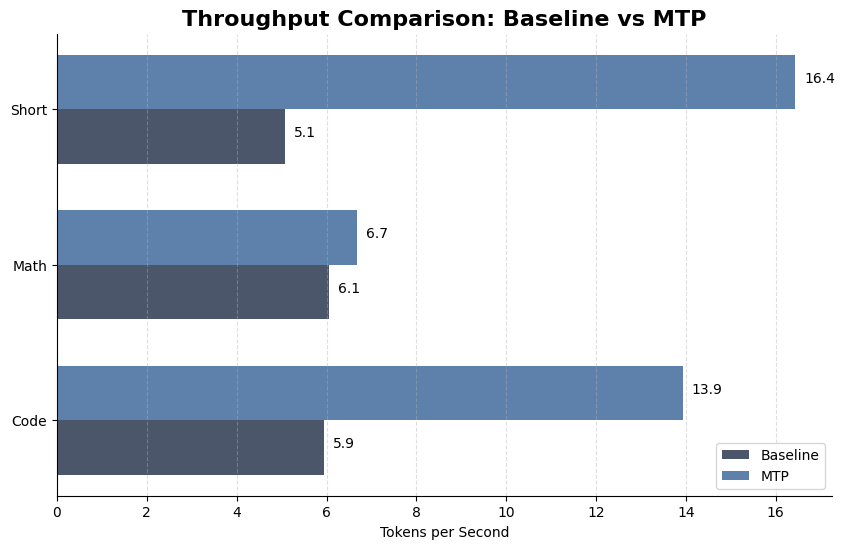

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# DATA PREPARATION
# ==============================

summary = results_df.groupby(
    ['prompt', 'mode']
)[['tokens_per_sec']].mean().reset_index()

throughput_pivot = summary.pivot(
    index='prompt',
    columns='mode',
    values='tokens_per_sec'
)

# ==============================
# COLORS
# ==============================

BASELINE_COLOR = '#4C566A'
MTP_COLOR = '#5E81AC'

# ==============================
# PLOT
# ==============================

fig, ax = plt.subplots(figsize=(10, 6))

prompts = throughput_pivot.index.tolist()

y = np.arange(len(prompts))
bar_width = 0.35

# Baseline
ax.barh(
    y - bar_width/2,
    throughput_pivot['baseline'],
    height=bar_width,
    color=BASELINE_COLOR,
    label='Baseline'
)

# MTP
ax.barh(
    y + bar_width/2,
    throughput_pivot['mtp'],
    height=bar_width,
    color=MTP_COLOR,
    label='MTP'
)

# Labels
for i, val in enumerate(throughput_pivot['baseline']):
    ax.text(val + 0.2, i - bar_width/2, f'{val:.1f}')

for i, val in enumerate(throughput_pivot['mtp']):
    ax.text(val + 0.2, i + bar_width/2, f'{val:.1f}')

# Formatting
ax.set_yticks(y)
ax.set_yticklabels(prompts)

ax.set_xlabel('Tokens per Second')
ax.set_title(
    'Throughput Comparison: Baseline vs MTP',
    fontsize=16,
    weight='bold'
)

ax.grid(axis='x', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()

plt.show()

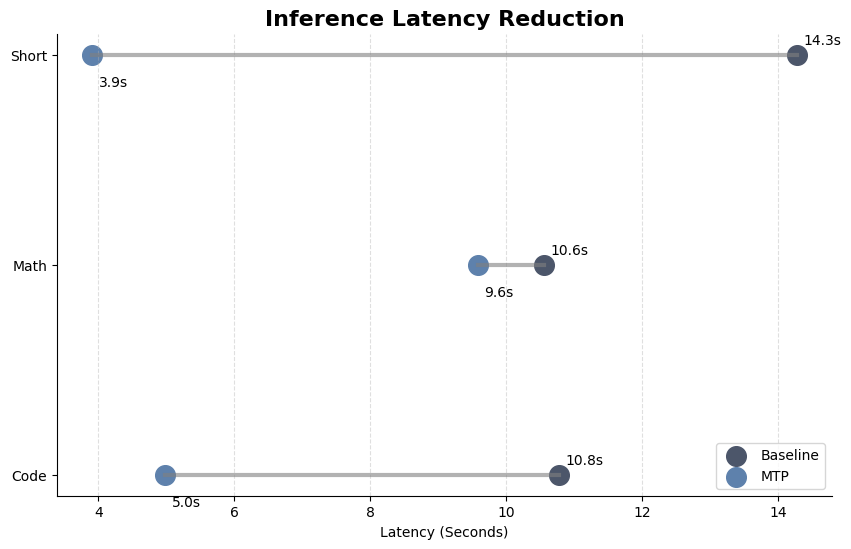

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# DATA PREPARATION
# ==============================

summary = results_df.groupby(
    ['prompt', 'mode']
)[['latency_s']].mean().reset_index()

latency_pivot = summary.pivot(
    index='prompt',
    columns='mode',
    values='latency_s'
)

# ==============================
# COLORS
# ==============================

BASELINE_COLOR = '#4C566A'
MTP_COLOR = '#5E81AC'

# ==============================
# PLOT
# ==============================

fig, ax = plt.subplots(figsize=(10, 6))

prompts = latency_pivot.index.tolist()

for i, prompt in enumerate(prompts):

    baseline_val = latency_pivot.loc[prompt, 'baseline']
    mtp_val = latency_pivot.loc[prompt, 'mtp']

    # Connecting Line
    ax.plot(
        [baseline_val, mtp_val],
        [i, i],
        color='gray',
        linewidth=3,
        alpha=0.6
    )

    # Baseline Point
    ax.scatter(
        baseline_val,
        i,
        color=BASELINE_COLOR,
        s=200,
        label='Baseline' if i == 0 else ""
    )

    # MTP Point
    ax.scatter(
        mtp_val,
        i,
        color=MTP_COLOR,
        s=200,
        label='MTP' if i == 0 else ""
    )

    # Labels
    ax.text(
        baseline_val + 0.1,
        i + 0.05,
        f'{baseline_val:.1f}s'
    )

    ax.text(
        mtp_val + 0.1,
        i - 0.15,
        f'{mtp_val:.1f}s'
    )

# Formatting
ax.set_yticks(range(len(prompts)))
ax.set_yticklabels(prompts)

ax.set_xlabel('Latency (Seconds)')

ax.set_title(
    'Inference Latency Reduction',
    fontsize=16,
    weight='bold'
)

ax.grid(axis='x', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()

plt.show()

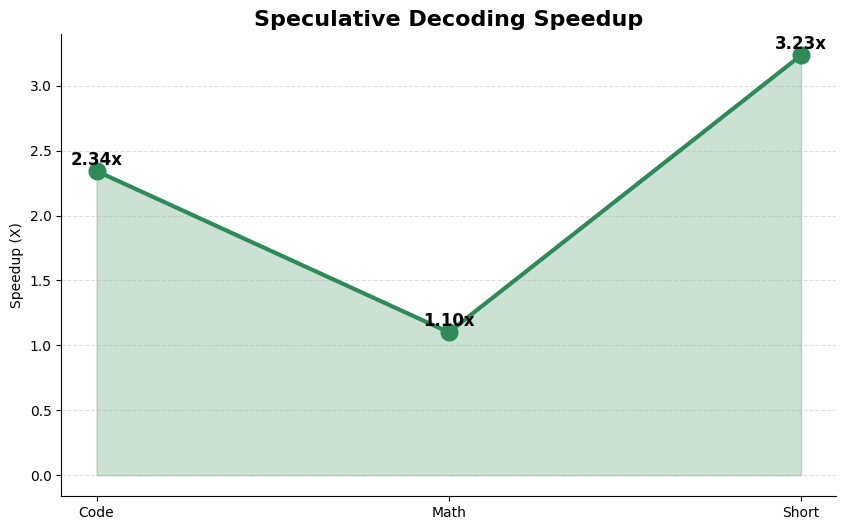

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# DATA PREPARATION
# ==============================

comparison = results_df.pivot_table(
    index='prompt',
    columns='mode',
    values='tokens_per_sec',
    aggfunc='mean'
)

comparison['speedup_x'] = (
    comparison['mtp'] / comparison['baseline']
)

# ==============================
# COLOR
# ==============================

SPEEDUP_COLOR = '#2E8B57'

# ==============================
# PLOT
# ==============================

fig, ax = plt.subplots(figsize=(10, 6))

prompts = comparison.index.tolist()

speedup_values = comparison['speedup_x'].values

# Line
ax.plot(
    prompts,
    speedup_values,
    marker='o',
    linewidth=3,
    markersize=12,
    color=SPEEDUP_COLOR
)

# Area Fill
ax.fill_between(
    prompts,
    speedup_values,
    alpha=0.25,
    color=SPEEDUP_COLOR
)

# Labels
for i, val in enumerate(speedup_values):
    ax.text(
        i,
        val + 0.05,
        f'{val:.2f}x',
        ha='center',
        fontsize=12,
        weight='bold'
    )

# Formatting
ax.set_ylabel('Speedup (X)')

ax.set_title(
    'Speculative Decoding Speedup',
    fontsize=16,
    weight='bold'
)

ax.grid(axis='y', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

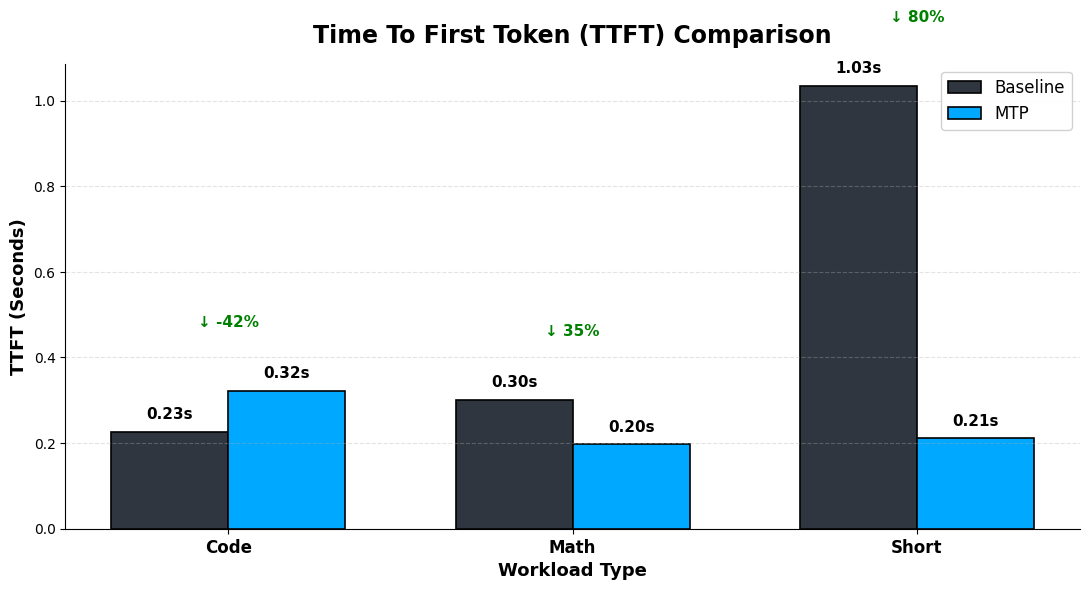

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# DATA PREPARATION
# ============================================================

summary = results_df.groupby(
    ['prompt', 'mode']
)[['ttft_s']].mean().reset_index()

ttft_pivot = summary.pivot(
    index='prompt',
    columns='mode',
    values='ttft_s'
)

# ============================================================
# PROFESSIONAL COLORS
# ============================================================

# Dark Gray
BASELINE_COLOR = '#2F3640'

# Bright Blue
MTP_COLOR = '#00A8FF'

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

prompts = ttft_pivot.index.tolist()

x = np.arange(len(prompts))
bar_width = 0.34

# ============================================================
# BASELINE BARS
# ============================================================

baseline_bars = ax.bar(
    x - bar_width/2,
    ttft_pivot['baseline'],
    width=bar_width,
    color=BASELINE_COLOR,
    edgecolor='black',
    linewidth=1.2,
    label='Baseline'
)

# ============================================================
# MTP BARS
# ============================================================

mtp_bars = ax.bar(
    x + bar_width/2,
    ttft_pivot['mtp'],
    width=bar_width,
    color=MTP_COLOR,
    edgecolor='black',
    linewidth=1.2,
    label='MTP'
)

# ============================================================
# VALUE LABELS
# ============================================================

for bar in baseline_bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.03,
        f'{height:.2f}s',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

for bar in mtp_bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.03,
        f'{height:.2f}s',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# ============================================================
# FORMATTING
# ============================================================

ax.set_xticks(x)
ax.set_xticklabels(
    prompts,
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'TTFT (Seconds)',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel(
    'Workload Type',
    fontsize=13,
    fontweight='bold'
)

ax.set_title(
    'Time To First Token (TTFT) Comparison',
    fontsize=17,
    fontweight='bold',
    pad=15
)

# Grid
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.35
)

# Remove top/right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Better legend
legend = ax.legend(
    fontsize=12,
    frameon=True
)

legend.get_frame().set_alpha(0.9)

# ============================================================
# OPTIONAL: ADD SPEEDUP TEXT
# ============================================================

for i in range(len(prompts)):

    baseline = ttft_pivot['baseline'].iloc[i]
    mtp = ttft_pivot['mtp'].iloc[i]

    reduction = ((baseline - mtp) / baseline) * 100

    ax.text(
        x[i],
        max(baseline, mtp) + 0.15,
        f'↓ {reduction:.0f}%',
        ha='center',
        fontsize=11,
        color='green',
        fontweight='bold'
    )

# ============================================================
# SHOW
# ============================================================

plt.tight_layout()

plt.show()

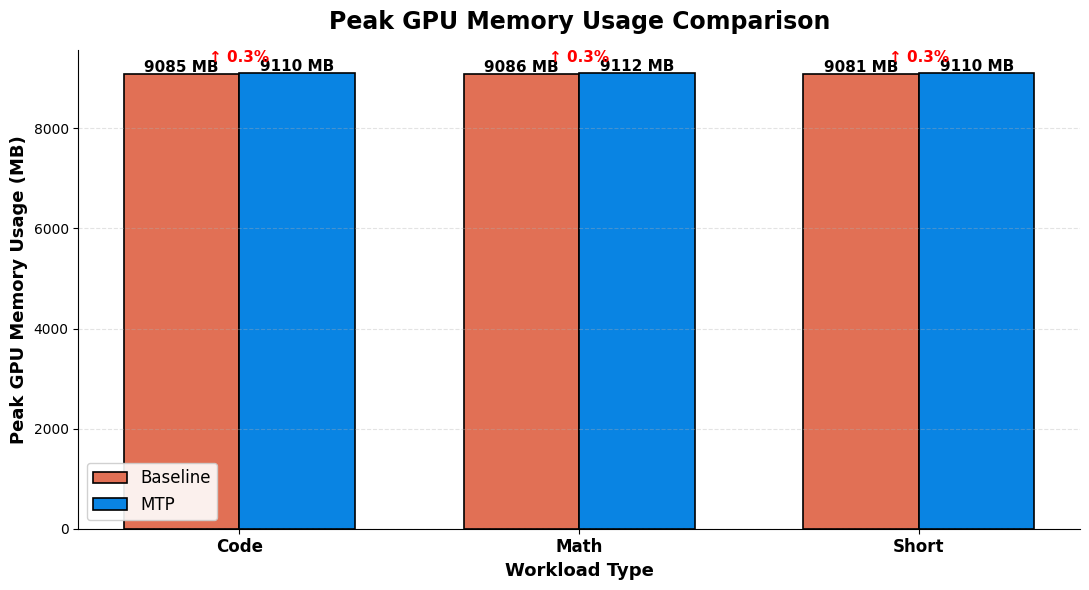

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# DATA PREPARATION
# ============================================================

summary = results_df.groupby(
    ['prompt', 'mode']
)[['peak_mem_mb']].mean().reset_index()

memory_pivot = summary.pivot(
    index='prompt',
    columns='mode',
    values='peak_mem_mb'
)

# ============================================================
# PROFESSIONAL COLORS
# ============================================================

# Dark Orange for Baseline
BASELINE_COLOR = '#E17055'

# Bright Blue for MTP
MTP_COLOR = '#0984E3'

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

prompts = memory_pivot.index.tolist()

x = np.arange(len(prompts))
bar_width = 0.34

# ============================================================
# BASELINE BARS
# ============================================================

baseline_bars = ax.bar(
    x - bar_width/2,
    memory_pivot['baseline'],
    width=bar_width,
    color=BASELINE_COLOR,
    edgecolor='black',
    linewidth=1.2,
    label='Baseline'
)

# ============================================================
# MTP BARS
# ============================================================

mtp_bars = ax.bar(
    x + bar_width/2,
    memory_pivot['mtp'],
    width=bar_width,
    color=MTP_COLOR,
    edgecolor='black',
    linewidth=1.2,
    label='MTP'
)

# ============================================================
# VALUE LABELS
# ============================================================

for bar in baseline_bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 40,
        f'{height:.0f} MB',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

for bar in mtp_bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 40,
        f'{height:.0f} MB',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# ============================================================
# FORMATTING
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    prompts,
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Peak GPU Memory Usage (MB)',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel(
    'Workload Type',
    fontsize=13,
    fontweight='bold'
)

ax.set_title(
    'Peak GPU Memory Usage Comparison',
    fontsize=17,
    fontweight='bold',
    pad=15
)

# ============================================================
# GRID
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.35
)

# ============================================================
# REMOVE EXTRA BORDERS
# ============================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ============================================================
# BETTER LEGEND
# ============================================================

legend = ax.legend(
    fontsize=12,
    frameon=True
)

legend.get_frame().set_alpha(0.9)

# ============================================================
# OPTIONAL MEMORY SAVING TEXT
# ============================================================

for i in range(len(prompts)):

    baseline = memory_pivot['baseline'].iloc[i]
    mtp = memory_pivot['mtp'].iloc[i]

    reduction = ((baseline - mtp) / baseline) * 100

    if reduction > 0:
        text = f'↓ {reduction:.1f}%'
        color = 'green'
    else:
        text = f'↑ {abs(reduction):.1f}%'
        color = 'red'

    ax.text(
        x[i],
        max(baseline, mtp) + 220,
        text,
        ha='center',
        fontsize=11,
        color=color,
        fontweight='bold'
    )

# ============================================================
# SHOW
# ============================================================

plt.tight_layout()

plt.show()